In [ ]:
#https://medium.com/luca-chuangs-bapm-notes/build-a-neural-network-in-python-multi-class-classification-e940f74bd899
import pandas as pd
import numpy as np
#from sklearn.preprocessing import LabelEncoder

#from keras.wrappers.scikit_learn import KerasClassifier
from keras.utils import to_categorical#

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)
data = pd.read_excel('/content/drive/My Drive/OrginalAQTehran.xlsx')

data.drop('Time',axis=1,inplace=True)
def probThreshold(inpProb):
    if inpProb  <  51:
        return(0)
    if 50<inpProb < 101:
        return(1)
    if 100<inpProb<151:
        return(2)
    if 150<inpProb<201:
        return(3)
    if 200<inpProb<301:
        return(4)
    else:
        return(5)

data['Outcomes']=data['AQI'].apply(probThreshold)
#print(data[1:10])

X=data.iloc[:,:-2].values
y=data.iloc[:,-1].values
X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=.15, random_state =12)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.176, random_state=12) #0.176 * 0.85 = 0.15

unique, counts = np.unique(y_train, return_counts=True)
print("TrainSet (class: count) = ", dict(zip(unique, counts)), "TestSize : ", y_train.shape[0])

unique, counts = np.unique(y_test, return_counts=True)
print("TestSet (class: count) =", dict(zip(unique, counts)), "TestSize : ", y_test.shape[0])

unique, counts = np.unique(y_val, return_counts=True)
print("ValSet (class: count) = ", dict(zip(unique, counts)), "ValSize : ", y_val.shape[0])

print(y.shape[0], " = ", (y_train.shape[0] + y_test.shape[0] + y_val.shape[0]))

Mounted at /content/drive
TrainSet (class: count) =  {0: 54, 1: 835, 2: 339, 3: 48, 4: 1, 5: 1} TestSize :  1278
TestSet (class: count) = {0: 12, 1: 185, 2: 70, 3: 7, 5: 1} TestSize :  275
ValSet (class: count) =  {0: 13, 1: 176, 2: 78, 3: 6, 4: 1} ValSize :  274
1827  =  1827


In [ ]:
dummy_y_train = to_categorical(y_train, 6)
print(dummy_y_train)

dummy_y_test = to_categorical(y_test, 6)
print(dummy_y_test)

dummy_y_val = to_categorical(y_val, 6)
print(dummy_y_val)

[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]


In [ ]:
#### Best hyperparamters ####
#{'batch_size': 30, 'epochs': 100, 'model__neurons_1': 20, 'model__neurons_2': 50, 'optimizer': 'rmsprop'}
#### Best hyperparamters #### val
#{'batch_size': 30, 'epochs': 100, 'model__neurons_1': 32, 'model__neurons_2': 41, 'optimizer': 'rmsprop'}
#del model
#del Sequential
from keras.models import Sequential
model = Sequential()
model.add(Dense(units=21, input_shape=(X_test.shape[1],), activation='relu')) # input shape is (features,)
model.add(Dense(units=48, activation='relu')) # input shape is (features,)
model.add(Dense(units=6, activation='softmax'))
model.summary()

# compile the model
#https://keras.io/api/models/model_training_apis/
model.compile(optimizer='RMSprop',
              loss='categorical_crossentropy', # this is different instead of binary_crossentropy (for regular classification)
              metrics=['accuracy'])

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 21)                315       
                                                                 
 dense_22 (Dense)            (None, 48)                1056      
                                                                 
 dense_23 (Dense)            (None, 6)                 294       
                                                                 
Total params: 1665 (6.50 KB)
Trainable params: 1665 (6.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
import keras
from keras.callbacks import EarlyStopping

# early stopping callback
# This callback will stop the training when there is no improvement in
#https://keras.io/api/callbacks/early_stopping/
es = keras.callbacks.EarlyStopping(monitor='val_loss', #val_accuracy #val_loss
                                   mode='auto',
                                   patience=200,
                                   restore_best_weights=True) # important - otherwise you just return the last weigths...

from keras.callbacks import ModelCheckpoint
mcp_save = ModelCheckpoint('/content/drive/My Drive/best_model.keras', save_best_only=True, monitor='val_loss', mode='auto') #.mdl_wts.hdf5
#reduce_lr_loss = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=200, verbose=1, epsilon=1e-4, mode='auto')

#model.fit(Xtr_more, Ytr_more, batch_size=batch_size, epochs=50, verbose=0, callbacks=[earlyStopping, mcp_save, reduce_lr_loss], validation_split=0.25)
# now we just update our model fit call
#https://keras.io/api/models/model_training_apis/
history = model.fit(X_train,
                    dummy_y_train,
                    callbacks=[es, mcp_save], #callbacks=[es],
                    epochs=5000, # you can set this to a big number!
                    batch_size=31 , #1 , 3 , 487 , 1461
                    shuffle=True,
                    validation_data=(X_val, dummy_y_val),
                    validation_batch_size = 19,
                   # validation_split=0.15,
                    verbose=2)

Epoch 1/5000
42/42 - 14s - loss: 56.8575 - accuracy: 0.4006 - val_loss: 19.5230 - val_accuracy: 0.6168 - 14s/epoch - 342ms/step
Epoch 2/5000
42/42 - 0s - loss: 12.1792 - accuracy: 0.6698 - val_loss: 4.7532 - val_accuracy: 0.6715 - 272ms/epoch - 6ms/step
Epoch 3/5000
42/42 - 0s - loss: 3.2891 - accuracy: 0.6729 - val_loss: 2.9002 - val_accuracy: 0.4854 - 286ms/epoch - 7ms/step
Epoch 4/5000
42/42 - 0s - loss: 2.3566 - accuracy: 0.6878 - val_loss: 5.4527 - val_accuracy: 0.6496 - 228ms/epoch - 5ms/step
Epoch 5/5000
42/42 - 0s - loss: 2.3229 - accuracy: 0.7011 - val_loss: 1.6763 - val_accuracy: 0.7007 - 265ms/epoch - 6ms/step
Epoch 6/5000
42/42 - 0s - loss: 2.1202 - accuracy: 0.7136 - val_loss: 1.1292 - val_accuracy: 0.7920 - 260ms/epoch - 6ms/step
Epoch 7/5000
42/42 - 0s - loss: 2.2229 - accuracy: 0.6917 - val_loss: 1.2082 - val_accuracy: 0.7737 - 239ms/epoch - 6ms/step
Epoch 8/5000
42/42 - 0s - loss: 1.5808 - accuracy: 0.7700 - val_loss: 2.9316 - val_accuracy: 0.4891 - 228ms/epoch - 5ms/s

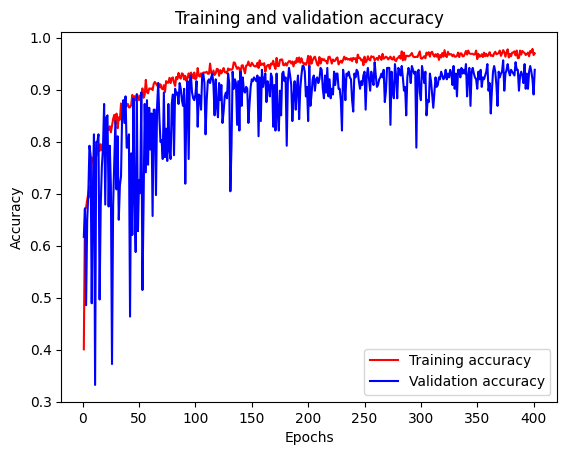

In [ ]:
import matplotlib.pyplot as plt
history_dict = history.history

# learning curve
# accuracy
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

# loss
loss = history_dict['loss']
val_loss = history_dict['val_loss']

# range of X (no. of epochs)
epochs = range(1, len(acc) + 1)

# plot
# "r" is for "solid red line"
plt.plot(epochs, acc, 'r', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
history_dict = history.history
#print(history_dict['accuracy'])
print(max(history_dict['accuracy']))
print(sum(history_dict['accuracy'])/len(history_dict['accuracy']))
#print(max(history_dict['val_accuracy']))
#print(sum(history_dict['val_accuracy'])/len(history_dict['val_accuracy']))

0.978090763092041
0.9328498014636765


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# load a saved model
#from keras.models import load_model
#saved_model = load_model('/content/drive/My Drive/best_model.keras')
#model = saved_model

preds = model.predict(X_test) # see how the model did!
#print(preds)
print(preds[0]) # i'm spreading that prediction across three nodes and they sum to 1
print(np.sum(preds[0])) # sum it up! Should be 1

matrix = confusion_matrix(y_test, preds.argmax(axis=1))
print(matrix)

# more detail on how well things were predicted
print(classification_report(y_test, preds.argmax(axis=1)))

9/9 [==============================] - 0s 6ms/step
[1.2751507e-06 9.9999863e-01 3.1274185e-11 2.5203227e-31 0.0000000e+00
 3.2794596e-36]
0.9999999
[[ 10   2   0   0   0]
 [  0 182   3   0   0]
 [  0   0  69   1   0]
 [  0   0   1   6   0]
 [  0   0   0   0   1]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.99      0.98      0.99       185
           2       0.95      0.99      0.97        70
           3       0.86      0.86      0.86         7
           5       1.00      1.00      1.00         1

    accuracy                           0.97       275
   macro avg       0.96      0.93      0.94       275
weighted avg       0.98      0.97      0.97       275



In [ ]:
from sklearn.metrics import accuracy_score,balanced_accuracy_score,f1_score
print(accuracy_score(dummy_y_test.argmax(axis=1),preds.argmax(axis=1)))
print(balanced_accuracy_score(dummy_y_test.argmax(axis=1),preds.argmax(axis=1)))
print(f1_score(dummy_y_test.argmax(axis=1),preds.argmax(axis=1),average='macro'))
print(classification_report(dummy_y_test.argmax(axis=1), preds.argmax(axis=1)))

0.9745454545454545
0.9319948519948522
0.9435437191534752
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.99      0.98      0.99       185
           2       0.95      0.99      0.97        70
           3       0.86      0.86      0.86         7
           5       1.00      1.00      1.00         1

    accuracy                           0.97       275
   macro avg       0.96      0.93      0.94       275
weighted avg       0.98      0.97      0.97       275



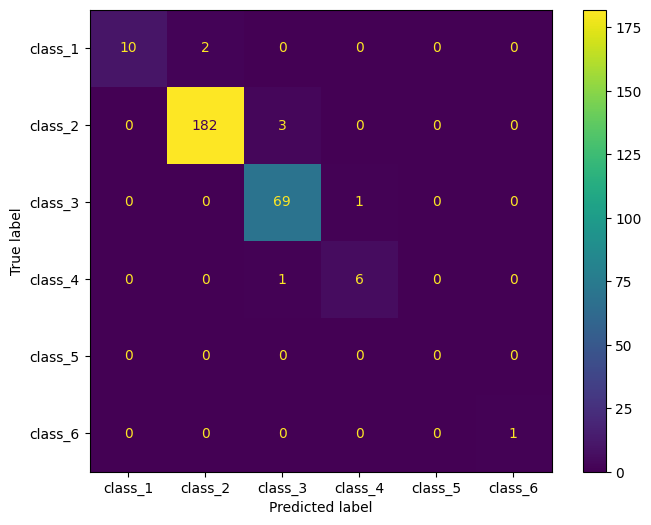

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 6))
cmp = ConfusionMatrixDisplay(confusion_matrix(y_test, preds.argmax(axis=1),
                             labels=[0, 1, 2, 3, 4, 5]),
                             display_labels=["class_1", "class_2", "class_3","class_4","class_5","class_6"])
cmp.plot(ax=ax)
plt.show()

In [ ]:
#https://michael-fuchs-python.netlify.app/2021/02/23/nn-artificial-neural-network-for-multi-class-classfication/
#https://machinelearningmastery.com/how-to-stop-training-deep-neural-networks-at-the-right-time-using-early-stopping/
#https://machinelearningmastery.com/use-keras-deep-learning-models-scikit-learn-python/

In [ ]:
#!pip install scikeras
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier


#def create_model(neurons_1,neurons_2,activation,optimizer,dropout):
def make_classification_ann(optimizer='rmsprop', neurons_1=50, neurons_2=20):
    from keras.models import Sequential
    from keras.layers import Dense

   # Creating the classifier ANN model
    classifier = Sequential()
    classifier.add(Dense(units=neurons_1, input_dim=X_train.shape[1], kernel_initializer='uniform', activation='relu'))
    classifier.add(Dense(units=neurons_2, kernel_initializer='uniform', activation='relu'))
    classifier.add(Dense(units=6, kernel_initializer='uniform', activation='softmax'))
    classifier.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return classifier


batch_size = [30]
epochs = [100]
Optimizer_Trial = ['rmsprop']
Neurons_Trial = [20, 32, 41, 50]
Neurons_Trial1 = [10, 16, 41, 60]

# # Creating the classifier ANN
param_grid = dict(optimizer=Optimizer_Trial, epochs=epochs, batch_size=batch_size, model__neurons_1=Neurons_Trial, model__neurons_2=Neurons_Trial1)
classifierModel=KerasClassifier(make_classification_ann, verbose=0)
#from scikeras.wrappers import KerasClassifier
#from sklearn.metrics import make_scorer, f1_score
#scorer = make_scorer(f1_score, average = 'weighted')
grid_search=GridSearchCV(estimator=classifierModel, param_grid=param_grid, scoring='accuracy', cv=6)

# ########################################

# # Measuring how much time it took to find the best params
import time
StartTime=time.time()

# # Running Grid Search for different paramenters
ResultsData = grid_search.fit(X_train, dummy_y_train, validation_data=(X_val, dummy_y_val), verbose=2)

EndTime=time.time()
print("############### Total Time Taken: ", round((EndTime-StartTime)/60), 'Minutes #############')

# printing the best parameters
print('\n#### Best hyperparamters ####')
print(grid_search.best_params_)
############### Total Time Taken:  98 Minutes #############
#{'batch_size': 30, 'epochs': 100, 'model__neurons_1': 20, 'model__neurons_2': 50, 'optimizer': 'rmsprop'}
# Printing the best parameter
#print(ResultsData.sort_values(by='Accuracy', ascending=False).head(1))

Streaming output truncated to the last 5000 lines.
Epoch 3/100
36/36 - 0s - loss: 0.8260 - accuracy: 0.6610 - val_loss: 0.8343 - val_accuracy: 0.6423 - 205ms/epoch - 6ms/step
Epoch 4/100
36/36 - 0s - loss: 0.7342 - accuracy: 0.6836 - val_loss: 0.7162 - val_accuracy: 0.6861 - 204ms/epoch - 6ms/step
Epoch 5/100
36/36 - 0s - loss: 0.6139 - accuracy: 0.7681 - val_loss: 0.5967 - val_accuracy: 0.7993 - 193ms/epoch - 5ms/step
Epoch 6/100
36/36 - 0s - loss: 0.5541 - accuracy: 0.7915 - val_loss: 0.5749 - val_accuracy: 0.7737 - 139ms/epoch - 4ms/step
Epoch 7/100
36/36 - 0s - loss: 0.5028 - accuracy: 0.8075 - val_loss: 0.5194 - val_accuracy: 0.8285 - 142ms/epoch - 4ms/step
Epoch 8/100
36/36 - 0s - loss: 0.4679 - accuracy: 0.8066 - val_loss: 0.5114 - val_accuracy: 0.8321 - 142ms/epoch - 4ms/step
Epoch 9/100
36/36 - 0s - loss: 0.4353 - accuracy: 0.8141 - val_loss: 0.5137 - val_accuracy: 0.8212 - 133ms/epoch - 4ms/step
Epoch 10/100
36/36 - 0s - loss: 0.4210 - accuracy: 0.8178 - val_loss: 0.6393 - va

AttributeError: 'GridSearchCV' object has no attribute 'sort_values'

In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

# Function to create model, required for KerasClassifier
def create_model(optimizer='rmsprop', init='uniform'):
    # create model
    model = Sequential()
    model.add(Dense(50, input_dim=8, kernel_initializer=init, activation='relu'))
    model.add(Dense(20, kernel_initializer=init, activation='relu'))
    model.add(Dense(6, kernel_initializer=init, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

model = KerasClassifier(model=create_model, verbose=0)
print(model.get_params().keys())
# grid search epochs, batch size and optimizer
optimizers = ['rmsprop', 'adam']
init = ['uniform']
epochs = [100]
batches = [20,30, 487]
param_grid = dict(optimizer=optimizers, epochs=epochs, batch_size=batches, model__init=init)
grid = GridSearchCV(estimator=model, param_grid=param_grid)
grid_result = grid.fit(X_train, dummy_y_test)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

ModuleNotFoundError: No module named 'scikeras'

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# load a saved model
from keras.models import load_model
saved_model = load_model('/content/drive/My Drive/best_model.keras')
model = saved_model

y_pred = model.predict(X_test) # see how the model did!
#print(preds)
print(y_pred[0]) # i'm spreading that prediction across three nodes and they sum to 1
print(np.sum(y_pred[0])) # sum it up! Should be 1

matrix = confusion_matrix(y_test, y_pred.argmax(axis=1))
print(matrix)

# more detail on how well things were predicted
print(classification_report(y_test, y_pred.argmax(axis=1)))

9/9 [==============================] - 0s 7ms/step
[1.2751507e-06 9.9999863e-01 3.1274185e-11 2.5203227e-31 0.0000000e+00
 3.2794596e-36]
0.9999999
[[ 10   2   0   0   0]
 [  0 182   3   0   0]
 [  0   0  69   1   0]
 [  0   0   1   6   0]
 [  0   0   0   0   1]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.99      0.98      0.99       185
           2       0.95      0.99      0.97        70
           3       0.86      0.86      0.86         7
           5       1.00      1.00      1.00         1

    accuracy                           0.97       275
   macro avg       0.96      0.93      0.94       275
weighted avg       0.98      0.97      0.97       275



0.9745454545454545
0.9319948519948522
0.9435437191534752
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.99      0.98      0.99       185
           2       0.95      0.99      0.97        70
           3       0.86      0.86      0.86         7
           5       1.00      1.00      1.00         1

    accuracy                           0.97       275
   macro avg       0.96      0.93      0.94       275
weighted avg       0.98      0.97      0.97       275



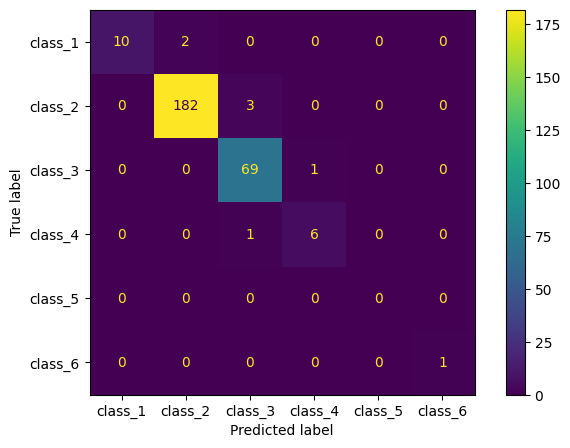

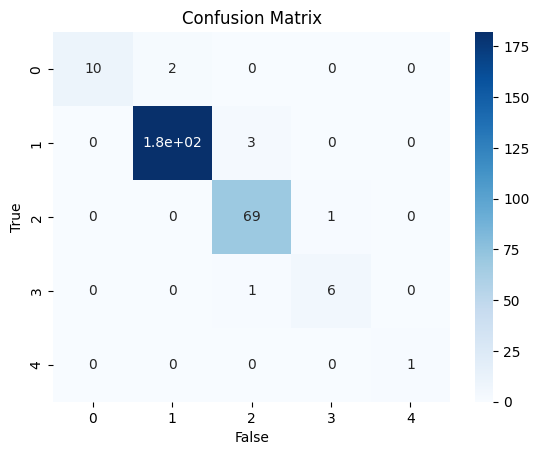

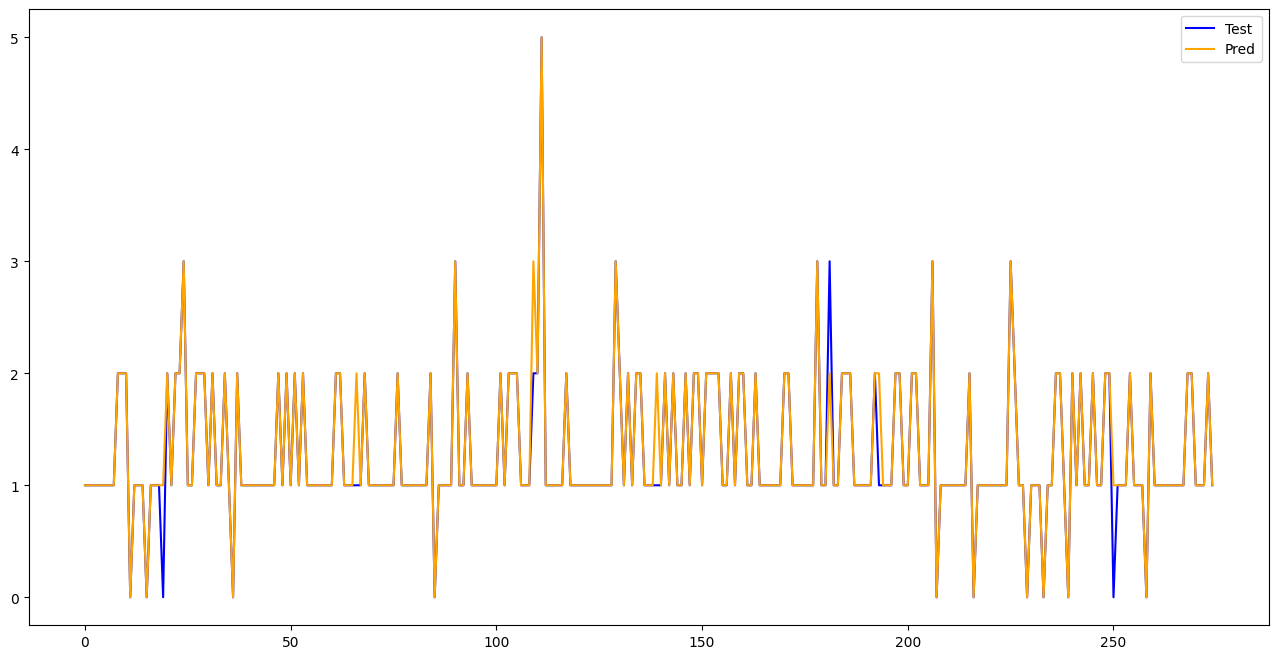

In [ ]:
from sklearn.metrics import classification_report,accuracy_score,balanced_accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print(accuracy_score(y_test, y_preds.argmax(axis=1)))
print(balanced_accuracy_score(y_test,y_pred.argmax(axis=1)))
print(f1_score(y_test,y_pred.argmax(axis=1),average='macro'))
print(classification_report(y_test, y_pred.argmax(axis=1)))
# dot_data = tree.export_graphviz(models, out_file=None, filled=True, rounded=True)
# graph = pydotplus.graph_from_dot_data(dot_data)
# display(Image(data=graph.create_png()))
fig, ax = plt.subplots(figsize=(8, 5))
cmp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred.argmax(axis=1), labels=[0, 1, 2, 3, 4, 5]), display_labels=["class_1", "class_2", "class_3","class_4","class_5","class_6"],)
cmp.plot(ax=ax)
plt.show()
conf_matrix = confusion_matrix(y_test, y_pred.argmax(axis=1))
sns.heatmap(conf_matrix, annot = True, cmap= 'Blues')
plt.ylabel('True')
plt.xlabel('False')
plt.title('Confusion Matrix')
plt.show()
plt.figure(figsize=(16,8))
plt.plot(y_test, color='blue', label='Test')
plt.plot(y_pred.argmax(axis=1), color='orange', label='Pred')
plt.legend()
plt.show()